--- Distribuição Absoluta ---
Vulnerable
0    15790
1     4210
Name: count, dtype: int64

--- Distribuição Percentual (%) ---
Vulnerable
0    78.95
1    21.05
Name: proportion, dtype: float64


C:\Users\pedro\AppData\Local\Temp\ipykernel_2224\1672623400.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Vulnerable', data=df, palette='RdYlGn')


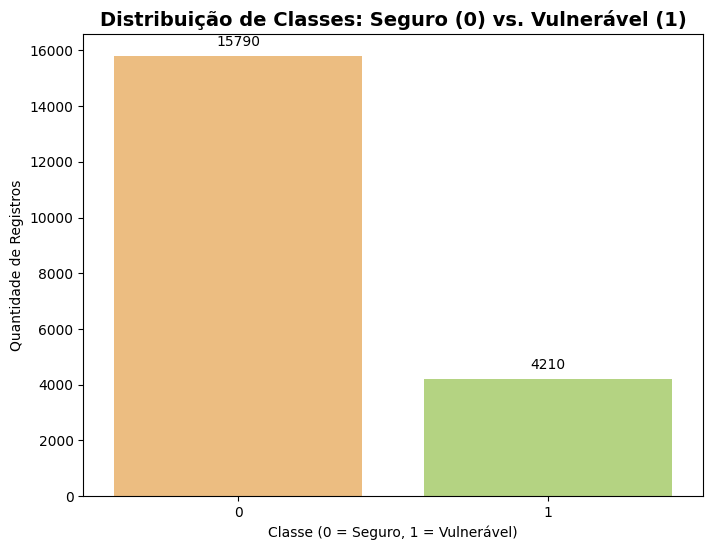

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# ==========================================
# 1. CARREGAMENTO DOS DADOS E TARGET
# ==========================================
df = pd.read_parquet('../../../dataset/data.parquet', engine='fastparquet')


# Variáveis auxiliares para o Target
df['perc_nao_essenciais'] = (df['Eating_Out'] + df['Entertainment']) / df['Income']
df['perc_emprestimo'] = df['Loan_Repayment'] / df['Income']

# Construção do Target (Pelo menos 2 condições verdadeiras)
df['Vulnerable'] = ((df['perc_emprestimo'] > 0.10).astype(int) +
                    (df['perc_nao_essenciais'] > 0.085).astype(int) +
                    ((df['Disposable_Income'] - df['Desired_Savings']) / df['Income'] < 0.10).astype(int) +
                    (df['Potential_Savings_Groceries'] / df['Income'] > 0.08).astype(int) >= 2).astype(int)

# ==========================================
# 2. CRIAÇÃO DAS FEATURES BASE
# ==========================================
df['Rent_Ratio'] = df['Rent'] / df['Income']
df['Healthcare_Ratio'] = df['Healthcare'] / df['Income']
df['Education_Ratio'] = df['Education'] / df['Income']
df['Groceries_Ratio'] = df['Groceries'] / df['Income']
df['Transport_Ratio'] = df['Transport'] / df['Income']
df['Utilities_Ratio'] = df['Utilities'] / df['Income']
df['Insurance_Ratio'] = df['Insurance'] / df['Income']

# ==========================================
# 3. ENGENHARIA DE FEATURES (Sem Vazamento)
# ==========================================
# Fator de Aperto
df['Total_Fixed_Ratio'] = (df['Rent_Ratio'] + df['Healthcare_Ratio'] +
                           df['Education_Ratio'] + df['Groceries_Ratio'] +
                           df['Transport_Ratio'] + df['Utilities_Ratio'] +
                           df['Insurance_Ratio'])

# Margem de Sobra Teórica
df['Remaining_Ratio'] = 1.0 - df['Total_Fixed_Ratio']

# Custo Fixo per Capita
df['Fixed_Cost_Per_Dependent'] = df['Total_Fixed_Ratio'] / (df['Dependents'] + 1)

# ==========================================
# 4. SELEÇÃO DE FEATURES E DIVISÃO (SPLIT)
# ==========================================
features_percentuais = [
    'Age', 'Dependents', 'Rent_Ratio', 'Healthcare_Ratio',
    'Education_Ratio', 'Groceries_Ratio', 'Transport_Ratio',
    'Utilities_Ratio', 'Insurance_Ratio',
    'Total_Fixed_Ratio', 'Remaining_Ratio', 'Fixed_Cost_Per_Dependent'
]

X = df[features_percentuais]
y = df['Vulnerable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 5. ANÁLISE DE DISTRIBUIÇÃO DAS CLASSES
# ==========================================
print("--- Distribuição Absoluta ---")
print(df['Vulnerable'].value_counts())

print("\n--- Distribuição Percentual (%) ---")
print((df['Vulnerable'].value_counts(normalize=True) * 100).round(2))

# Plotando o gráfico de barras com os rótulos de quantidade
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Vulnerable', data=df, palette='RdYlGn')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.title('Distribuição de Classes: Seguro (0) vs. Vulnerável (1)', fontsize=14, fontweight='bold')
plt.xlabel('Classe (0 = Seguro, 1 = Vulnerável)')
plt.ylabel('Quantidade de Registros')
plt.show()

In [2]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

# O fit aprende os parâmetros APENAS com o conjunto de treino (Evita Leakage)
X_train_scaled = scaler.fit_transform(X_train)

# O transform apenas aplica os mesmos limites aprendidos no conjunto de teste
X_test_scaled = scaler.transform(X_test)

# Convertendo de volta para DataFrame para manter a usabilidade e nomes de colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("--- Processo de Normalização Concluído com Sucesso ---")
print(f"X_train original: {X_train.shape} | X_train normalizado: {X_train_scaled.shape}")
print(f"X_test original:  {X_test.shape}  | X_test normalizado:  {X_test_scaled.shape}")

--- Processo de Normalização Concluído com Sucesso ---
X_train original: (16000, 12) | X_train normalizado: (16000, 12)
X_test original:  (4000, 12)  | X_test normalizado:  (4000, 12)
